In [1]:
### Multi-Task Regression: Beijing climate data set
library(glmnet) # lasso and ridge regression
library(rrpack)    # package for nuclear-norm penalized reduced-rank regression
library(dplyr)
library(ggplot2)
library(tidyverse)

Loading required package: Matrix

Loaded glmnet 4.1-10


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ──────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
###
data_all <- readRDS("../../data/climate/data_all.rds")

In [4]:
# coarsening of the categorical variable wind direction
# after merging categories, wind directions are "East", "NorthEast", "Northwest", "SouthEast", "SouthWest", "West"
data_all <- data_all %>%
  mutate(wd_coarse = case_match(wd,
    c("ENE", "ESE") ~ "E",
    "NNE"                ~ "NE",
    "NNW"                ~ "NW",
    "SSE"                ~ "SE",
    "SSW"                ~ "SW",
    c("WNW", "WSW")      ~ "W",
    .default = wd
  ))

data_all$wd_coarse <- as.factor(data_all$wd_coarse)

In [5]:
# data preparation continued:
# - subsetting to station 'Nongzhanguan', 
# - extract outcome and predictor variables, set coding of wd_coarse
dat <- data_all %>% filter(data_all$station == "Nongzhanguan") %>%
                select(PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, RAIN, WSPM, wd_coarse)
                           
# here wind direction is converted corresponding to the sum-to-zero constraint for the regression coefficients
contrasts(dat$wd_coarse) <- contr.sum(nlevels(dat$wd_coarse))

In [10]:
### partition "dat" into three chunks
### --- training
### --- validation: model selection
### --- test: model evaluation
trainix <- seq(from = 1, to = nrow(dat), by = 3)
validix <- seq(from = 2, to = nrow(dat), by = 3)
testix <- seq(from = 3, to = nrow(dat), by = 3)
# training
dat_train <- dat[trainix,]
# validation
dat_valid <- dat[validix,]
# test
dat_test <- dat[testix,]

# Here, we generate design matrices and response vector for the three data subsets (training, validation, testing)
# the function model.matrix is quite useful. 
# It extracts/generates the design matrix ("X") that corresponds to a model formula
Xtrain <- model.matrix(~ TEMP + PRES + RAIN + (WSPM * as.factor(wd_coarse)), data = dat_train)
ytrain  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% trainix))
colnames(ytrain) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
ntrain <- nrow(ytrain)

Xvalid <- model.matrix(~ TEMP + PRES + RAIN + (WSPM * as.factor(wd_coarse)), data = dat_valid)
yvalid  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% validix))
colnames(yvalid) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
nvalid <- nrow(yvalid)

Xtest <- model.matrix(~ TEMP + PRES + RAIN + (WSPM * as.factor(wd_coarse)), data = dat_test)
ytest  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% testix))
colnames(ytest) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
ntest <- nrow(ytest)

In [72]:
### NEW METHOD: 
# nuclear-norm penalized low-rank regression
# (implemented in the 'rrpack' R package)
#  
# ||Y - X B|_F^2 + \lambda * ||B||_{nuc}
#
# where ||B||_{nuc} is the sum of singular values ('nuclear norm') of B
lambda_grid <- exp(seq(from = -5, to = 3, length = 100))
rank_grid <- numeric(length(lambda_grid))
mse_valid <- numeric(length(lambda_grid))

for(i in 1:length(lambda_grid)){

    nucrr_train <- rrr(Y = ytrain, X = Xtrain, penaltySVD = "ann", modstr = list(lambda = lambda_grid[i], gamma = 0))
    mse_valid[i] <- mean((yvalid - Xvalid %*% nucrr_train$coef)^2)
    rank_grid[i] <- nucrr_train$rank
}

In [74]:
rank_grid

[1] 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 [38] 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 [75] 6 6 6 6 6 6 6 6 6 6 6 6 6 6 5 5 5 5 4 4 4 4 4 4 4 4

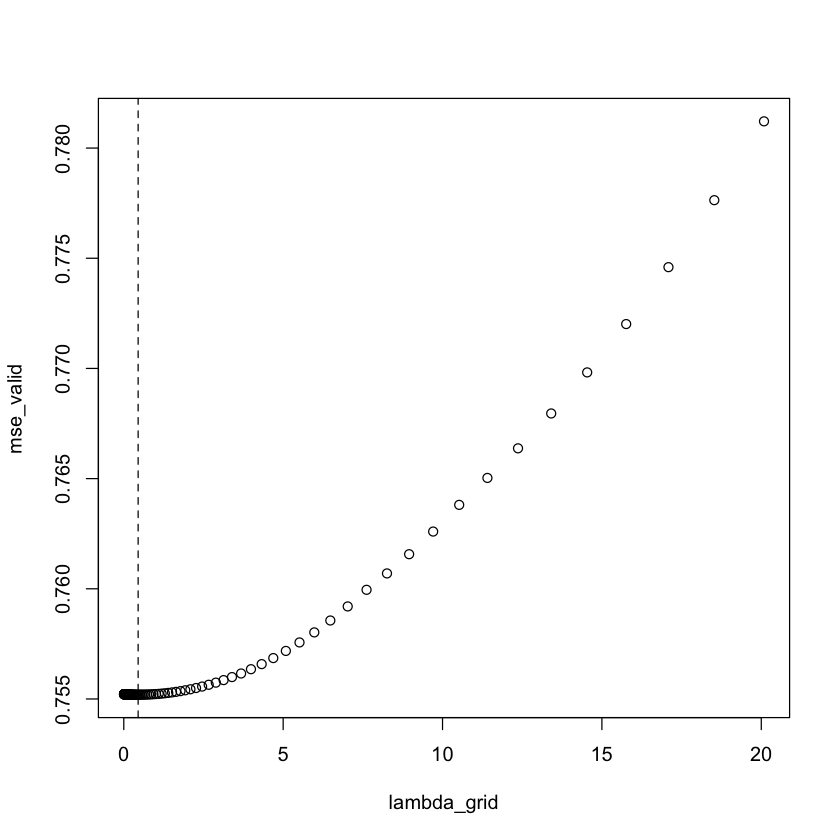

In [71]:
# trace validation error as a function of lambda
plot(lambda_grid, mse_valid)
abline(v = lambda_grid[which.min(mse_valid)], lty = "dashed")

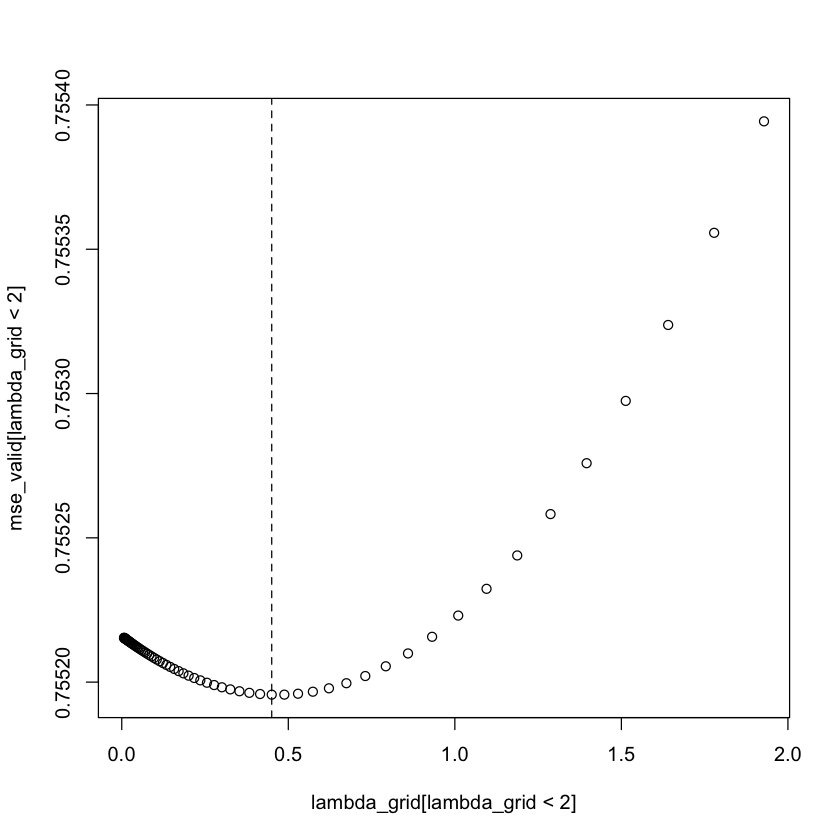

In [79]:
# zoom in
plot(lambda_grid[lambda_grid < 2], mse_valid[lambda_grid < 2])
abline(v = lambda_grid[which.min(mse_valid)], lty = "dashed")

In [87]:
# re-fit and evaluate test error 

# globally optimal 
lambda_star <- lambda_grid[which.min(mse_valid)]
# smallest lambda such that the rank of the B matrix is smallest over all lambda values test (here 4)
lambda_star_4 <- min(lambda_grid[rank_grid <= 4])
#
nucrr_opt <- rrr(Y = ytrain, X = Xtrain, penaltySVD = "ann", modstr = list(lambda = lambda_star, gamma = 0))
nucrr_opt_4 <- rrr(Y = ytrain, X = Xtrain, penaltySVD = "ann", modstr = list(lambda = lambda_star_4, gamma = 0))

In [89]:
# compute the MSEs on the test set
mean((ytest - Xtest %*% nucrr_opt$coef)^2) # optimal lambda
mean((ytest - Xtest %*% nucrr_opt_4$coef)^2) # rank4
mean((ytest - Xtest %*% nucrr_opt$coef.ls)^2) # OLS

[1] 0.7587317

[1] 0.7692939

[1] 0.7586993

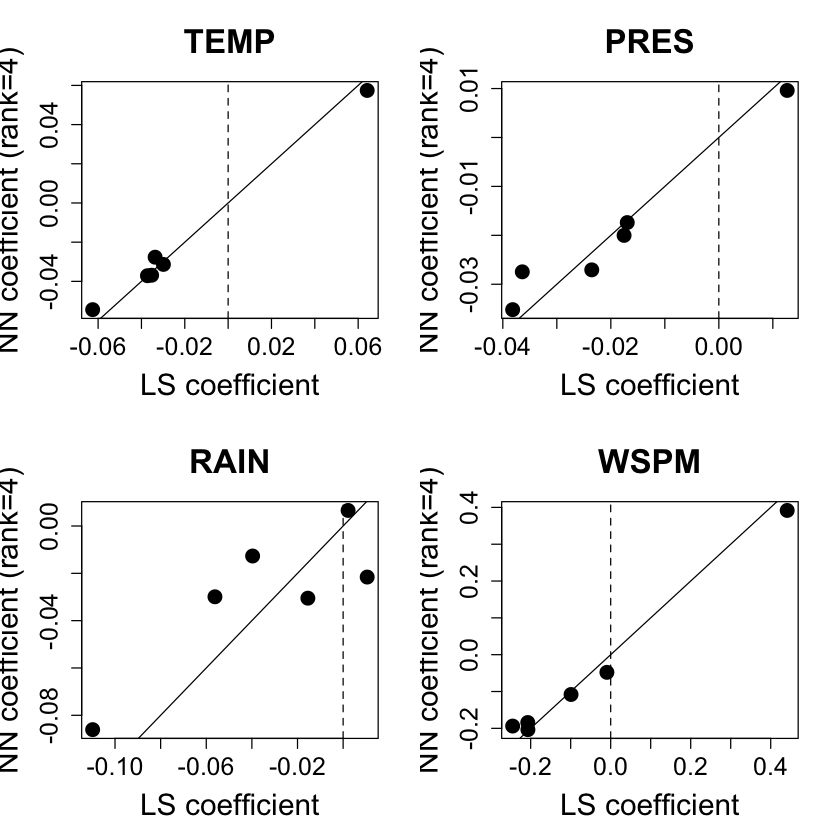

In [114]:
# Comparing the regression coefficients for the 
# least squares solution and nuclear-norm penalized solution
# for the first 4 predictor variables (main effects of continuous variables)
# 
# We expect that the nuclear-norm penalized solution undergoes
# some degree of shrinkage towards zero. This is actually confirmed 
# by the plots. The effect is most visible for the variable "RAIN". 

par(mfrow = c(2,2))
plot(nucrr_opt$coef.ls["TEMP",], nucrr_opt_4$coef["TEMP",],
    xlab = "LS coefficient", ylab = "NN coefficient (rank=4)", main = "TEMP", cex = 2, pch = 16,
    cex.axis = 1.5, cex.lab = 1.8, cex.main = 2)
abline(0,1)
abline(v = 0, lty = "dashed")

plot(nucrr_opt$coef.ls["PRES",], nucrr_opt_4$coef["PRES",],
    xlab = "LS coefficient", ylab = "NN coefficient (rank=4)", main = "PRES", cex = 2, pch = 16, 
    cex.axis = 1.5, cex.lab = 1.8, cex.main = 2)
abline(0,1)
abline(v = 0, lty = "dashed")

plot(nucrr_opt$coef.ls["RAIN",], nucrr_opt_4$coef["RAIN",],
    xlab = "LS coefficient", ylab = "NN coefficient (rank=4)", main = "RAIN", cex = 2, pch = 16, 
    cex.axis = 1.5, cex.lab = 1.8, cex.main = 2)
abline(0,1)
abline(v = 0, lty = "dashed")

plot(nucrr_opt$coef.ls["WSPM",], nucrr_opt_4$coef["WSPM",],
    xlab = "LS coefficient", ylab = "NN coefficient (rank=4)", main = "WSPM", cex = 2, pch = 16, 
    cex.axis = 1.5, cex.lab = 1.8, cex.main = 2)
abline(0,1)
abline(v = 0, lty = "dashed")